In [33]:
from project.ETL.load import Load
from project.config import settings
from os.path import join
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data_path = settings.paths.data_path
output_table_name= settings.paths.output_table_name
output_db_path = join(data_path,f'{output_table_name}.db')
print(output_db_path)
df = Load(output_db_path).load_from_sqlite(output_table_name)
df = df.set_index("origin")

/home/cip/ce/ix05ogym/Majid/MADE/data/international_students_north_america.db


In [34]:
us_column = ['2015_US','2016_US', '2017_US', '2018_US', '2019_US', '2020_US', '2021_US', '2022_US']
canada_column = ['2015_Canada', '2016_Canada', '2017_Canada', '2018_Canada', '2019_Canada', '2020_Canada', '2021_Canada', '2022_Canada']

us = df[us_column]
canada = df[canada_column]

us.columns = [col.replace('_US', '') for col in us.columns]
canada.columns = [col.replace('_Canada', '') for col in canada.columns]

us = us.astype('float')
canada = canada.astype('float')

/tmp/ipykernel_1609596/662276307.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(-s.iloc[0:10],palette="Blues_r")


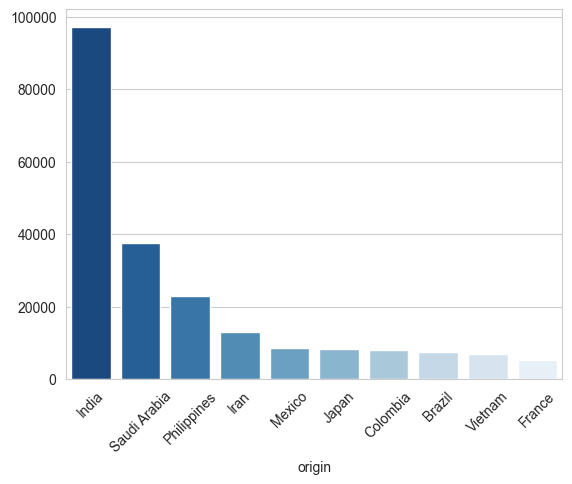

/tmp/ipykernel_1609596/662276307.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(s.iloc[-10:],palette="Reds")


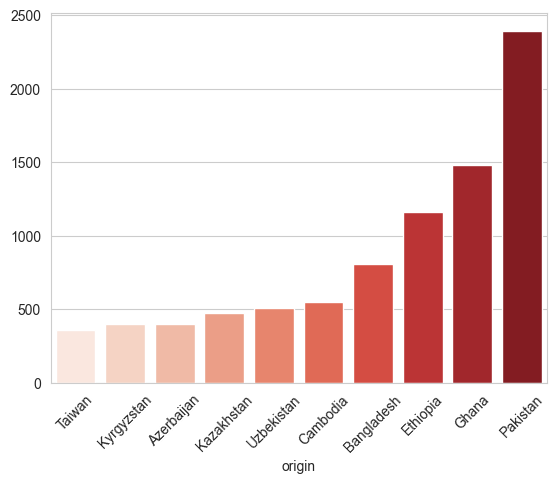

In [35]:
#d = (us - canada)#/sums
d= (us - canada)
d = d.dropna()
s = d['2022']-d['2015']
s = s.sort_values()
s = s
sns.barplot(-s.iloc[0:10],palette="Blues_r")
plt.xticks(rotation=45)

plt.show()
sns.barplot(s.iloc[-10:],palette="Reds")
plt.xticks(rotation=45)
plt.show()


In [36]:
us+canada

,2015,2016,2017,2018,2019,2020,2021,2022
origin,,,,,,,,
Afghanistan,593.0,621.0,571.0,498.0,517.0,444.0,500.0,852.0
Albania,820.0,946.0,1069.0,1238.0,1470.0,1303.0,1331.0,1432.0
Algeria,1218.0,1037.0,1232.0,1728.0,2929.0,2389.0,3433.0,5662.0
Andorra,11.0,16.0,14.0,17.0,11.0,16.0,28.0,25.0
Angola,1361.0,1337.0,1223.0,1039.0,934.0,703.0,591.0,628.0
...,...,...,...,...,...,...,...,...
Vietnam,24383.0,27933.0,34455.0,37092.0,35907.0,31621.0,30383.0,32265.0
Western Sahara,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Yemen,774.0,868.0,782.0,673.0,595.0,553.0,515.0,475.0


<Axes: ylabel='Saudi Arabia'>

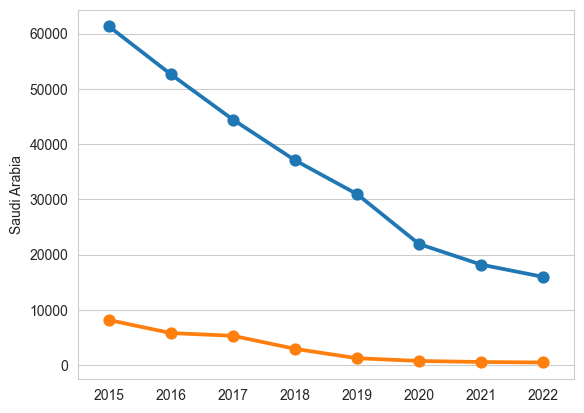

In [37]:
sns.pointplot(us.loc['Saudi Arabia'])
sns.pointplot(canada.loc['Saudi Arabia'])


<Axes: ylabel='India'>

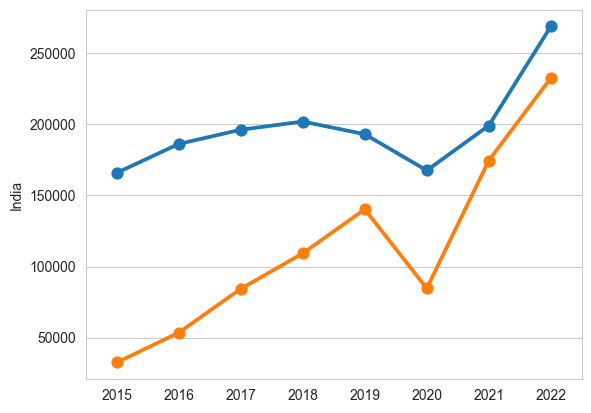

In [38]:
sns.pointplot(us.loc['India'])
sns.pointplot(canada.loc['India'])

<Axes: ylabel='Pakistan'>

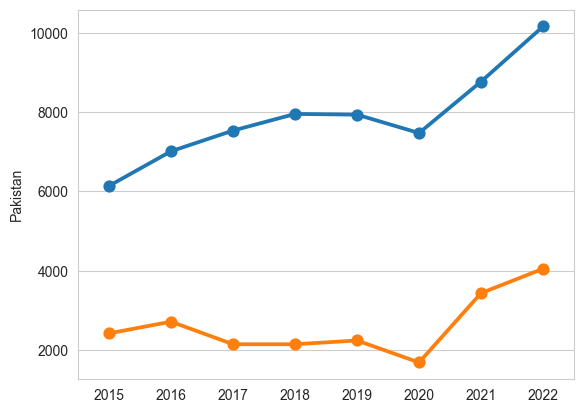

In [39]:
sns.pointplot(us.loc['Pakistan'])
sns.pointplot(canada.loc['Pakistan'])

<Axes: ylabel='Philippines'>

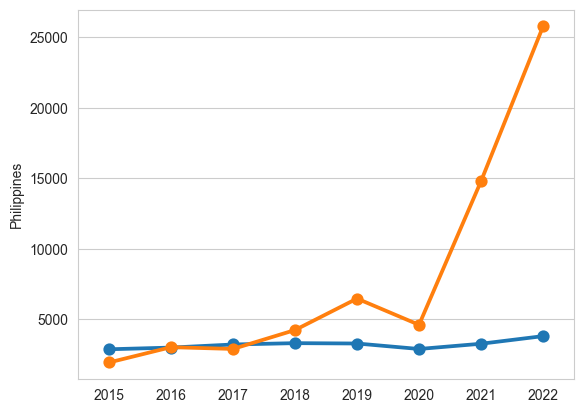

In [40]:
sns.pointplot(us.loc['Philippines'])
sns.pointplot(canada.loc['Philippines'])

<Axes: ylabel='Ukraine'>

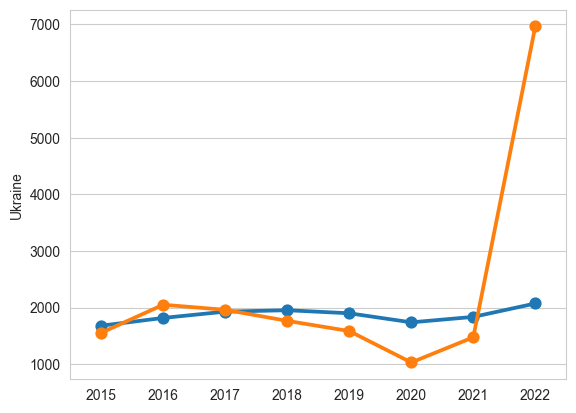

In [41]:
sns.pointplot(us.loc['Ukraine'])
sns.pointplot(canada.loc['Ukraine'])

In [42]:
c = canada > us
c2 = ~c
u1 =us[c2]['2015'].dropna()
u2 = us[c]['2022'].dropna()
intersection = u1.index.intersection(u2.index)
intersection

Index(['Barbados', 'Bhutan', 'Burundi', 'Colombia', 'Cuba', 'Haiti', 'Iran',
       'Madagascar', 'Mauritania', 'Philippines', 'Sri Lanka', 'Ukraine'],
      dtype='object', name='origin')

In [43]:
c = canada > us

u1 =us[c]['2015'].dropna()
u2 = us[~c]['2022'].dropna()
intersection = u1.index.intersection(u2.index)
u1

origin
Algeria                      158.0
Central African Republic      13.0
France                      8764.0
Mauritius                    250.0
Morocco                     1495.0
New Caledonia                  2.0
Senegal                      603.0
Stateless                     10.0
Tunisia                      692.0
Name: 2015, dtype: float64

/tmp/ipykernel_1609596/4106764805.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(-s.iloc[0:10],palette="Blues_r")


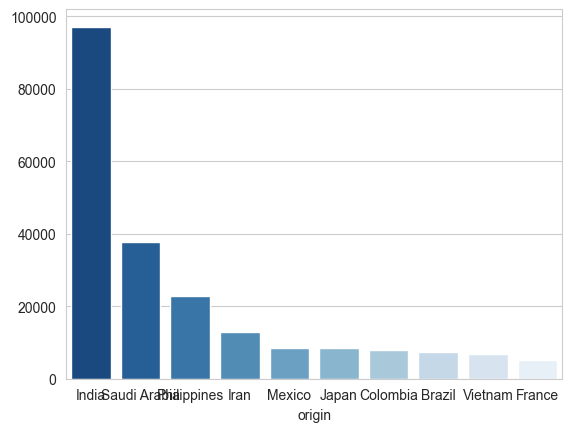

/tmp/ipykernel_1609596/4106764805.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(s.iloc[-10:],palette="Reds")


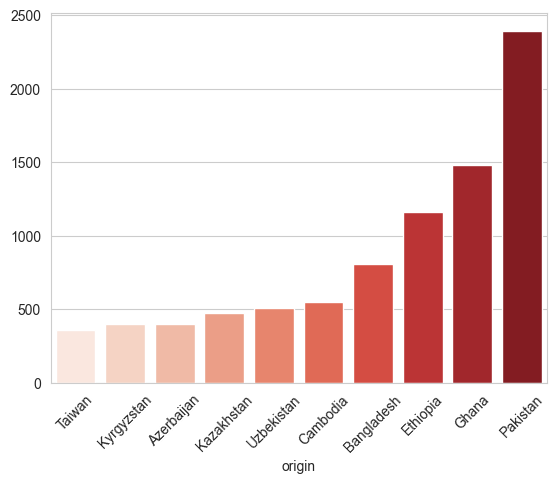

In [44]:
d= (us - canada)
d = d.dropna()
s = d['2022']-d['2015']
s = s.sort_values()
s = s
sns.barplot(-s.iloc[0:10],palette="Blues_r")
plt.show()
sns.barplot(s.iloc[-10:],palette="Reds")
plt.xticks(rotation=45)
plt.show()


In [45]:
sums = us + canada
_sum = sums.sum()
sums = sums/_sum
sums

,2015,2016,2017,2018,2019,2020,2021,2022
origin,,,,,,,,
Afghanistan,0.000850,0.000834,0.000716,0.000599,0.000604,0.000666,0.000557,0.000772
Albania,0.001175,0.001270,0.001341,0.001489,0.001718,0.001955,0.001483,0.001298
Algeria,0.001745,0.001393,0.001545,0.002079,0.003424,0.003584,0.003826,0.005131
Andorra,0.000016,0.000021,0.000018,0.000020,0.000013,0.000024,0.000031,0.000023
Angola,0.001950,0.001795,0.001534,0.001250,0.001092,0.001055,0.000659,0.000569
...,...,...,...,...,...,...,...,...
Vietnam,0.034939,0.037512,0.043221,0.044625,0.041972,0.047440,0.033862,0.029242
Western Sahara,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Yemen,0.001109,0.001166,0.000981,0.000810,0.000695,0.000830,0.000574,0.000430


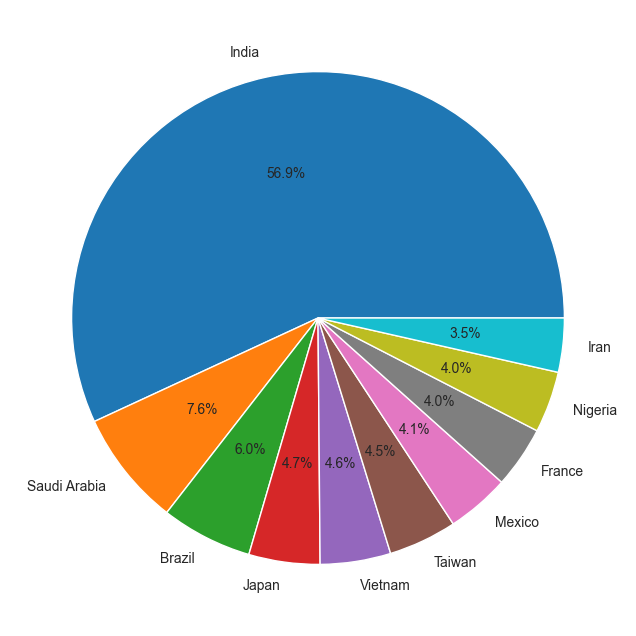

origin
Peru           0.002606
Ghana          0.002825
Algeria        0.003386
Ukraine        0.003555
Colombia       0.004720
Nepal          0.005888
Nigeria        0.006614
Bangladesh     0.007878
Philippines    0.019886
India          0.170299
Name: 2022, dtype: float64

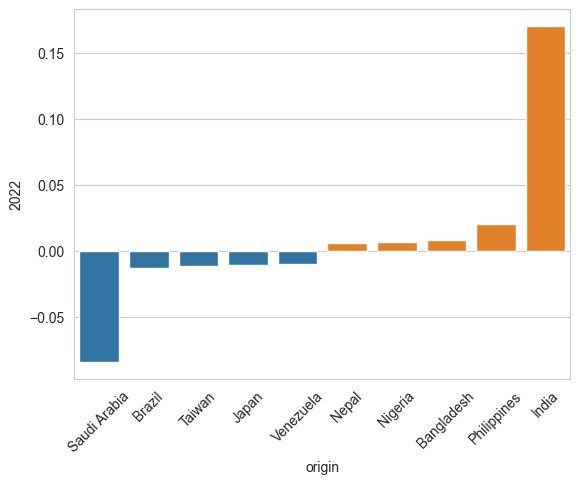

In [46]:
x:pd.DataFrame= sums.sort_values(by='2015', ascending=False)
sns.set_style("whitegrid")
plt.figure(figsize=(8, 8))
plt.pie(x.sum(axis=1).nlargest(10),labels=x.index[:10],autopct='%1.1f%%' )


plt.xticks(rotation=45)
plt.show()
x = x.diff(periods=7,axis=1)['2022'].sort_values(ascending=True)
sns.barplot(x.iloc[:5])
sns.barplot(x.iloc[-5:])
plt.xticks(rotation=45)
x.tail(10)

In [47]:
corr = us.corrwith(canada,1)
corr

origin
Afghanistan       0.917571
Albania           0.933949
Algeria           0.884331
Andorra           0.591715
Angola           -0.008418
                    ...   
Vietnam           0.516716
Western Sahara         NaN
Yemen            -0.249574
Zambia            0.869508
Zimbabwe          0.897891
Length: 154, dtype: float64

In [48]:
result = pd.concat([df, corr], axis=1,).rename(columns={0:'corr'})
result

,Unnamed: 0,2015_US,2016_US,2017_US,2018_US,2019_US,2020_US,2021_US,2022_US,2015_Canada,2016_Canada,2017_Canada,2018_Canada,2019_Canada,2020_Canada,2021_Canada,2022_Canada,corr
origin,,,,,,,,,,,,,,,,,,
Afghanistan,0,498.0,506.0,476.0,418.0,422.0,354.0,420.0,682.0,95.0,115.0,95.0,80.0,95.0,90.0,80.0,170.0,0.917571
Albania,1,705.0,781.0,884.0,993.0,1095.0,1053.0,1026.0,1087.0,115.0,165.0,185.0,245.0,375.0,250.0,305.0,345.0,0.933949
Algeria,2,158.0,192.0,212.0,238.0,239.0,219.0,268.0,302.0,1060.0,845.0,1020.0,1490.0,2690.0,2170.0,3165.0,5360.0,0.884331
Andorra,3,11.0,16.0,14.0,17.0,11.0,16.0,18.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,5.0,0.591715
Angola,4,1296.0,1257.0,1183.0,1014.0,814.0,673.0,541.0,553.0,65.0,80.0,40.0,25.0,120.0,30.0,50.0,75.0,-0.008418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vietnam,149,21403.0,22438.0,24325.0,24392.0,23777.0,21631.0,20713.0,21900.0,2980.0,5495.0,10130.0,12700.0,12130.0,9990.0,9670.0,10365.0,0.516716
Western Sahara,150,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
Yemen,151,599.0,658.0,517.0,398.0,320.0,293.0,305.0,305.0,175.0,210.0,265.0,275.0,275.0,260.0,210.0,170.0,-0.249574


In [49]:
#df = df.merge(result)
#columns_to_select = ['origin','corr'] +  list(us.columns) + list
result = result.sort_values(by='corr')
result = result.dropna()
result

,Unnamed: 0,2015_US,2016_US,2017_US,2018_US,2019_US,2020_US,2021_US,2022_US,2015_Canada,2016_Canada,2017_Canada,2018_Canada,2019_Canada,2020_Canada,2021_Canada,2022_Canada,corr
origin,,,,,,,,,,,,,,,,,,
Barbados,15,319.0,319.0,322.0,333.0,298.0,339.0,269.0,287.0,190.0,235.0,240.0,265.0,300.0,180.0,365.0,315.0,-0.881592
Tajikistan,135,235.0,204.0,222.0,229.0,242.0,205.0,183.0,170.0,0.0,10.0,15.0,10.0,10.0,10.0,20.0,35.0,-0.819153
El Salvador,42,1632.0,1570.0,1554.0,1566.0,1581.0,1492.0,1445.0,1309.0,180.0,225.0,280.0,290.0,275.0,195.0,270.0,405.0,-0.743765
Mauritania,91,97.0,103.0,106.0,84.0,67.0,53.0,53.0,41.0,35.0,30.0,60.0,65.0,65.0,55.0,80.0,80.0,-0.729479
Iran,65,12269.0,12643.0,12783.0,12142.0,11451.0,9614.0,9295.0,10812.0,2405.0,3095.0,4860.0,7260.0,10060.0,7435.0,12420.0,13890.0,-0.694610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Libya,81,1514.0,1311.0,1064.0,884.0,720.0,563.0,472.0,449.0,1480.0,1030.0,805.0,530.0,540.0,480.0,310.0,340.0,0.962598
Kenya,73,3019.0,3189.0,3322.0,3451.0,3710.0,3502.0,3799.0,4059.0,440.0,695.0,810.0,1050.0,1085.0,870.0,1230.0,1355.0,0.964616
Argentina,7,2201.0,2219.0,2283.0,2407.0,2428.0,2184.0,2718.0,2979.0,160.0,180.0,200.0,230.0,275.0,190.0,585.0,620.0,0.964843


origin
Barbados       -0.881592
Tajikistan     -0.819153
El Salvador    -0.743765
Mauritania     -0.729479
Iran           -0.694610
Iraq           -0.685853
Bermuda        -0.626924
Grenada        -0.618185
Kuwait         -0.593804
Cuba           -0.545697
Costa Rica      0.942436
Bolivia         0.943211
Lebanon         0.949120
Spain           0.961080
Taiwan          0.962594
Libya           0.962598
Kenya           0.964616
Argentina       0.964843
Saudi Arabia    0.975608
Name: corr, dtype: float64


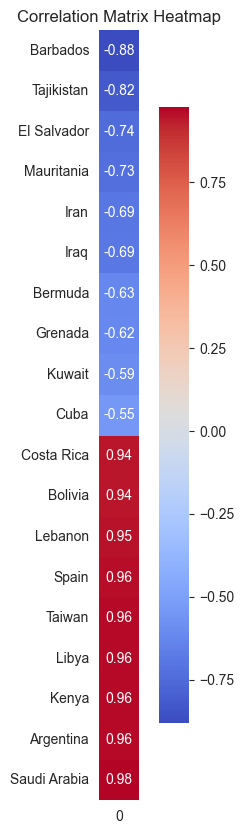

In [50]:
plt.figure(figsize=(5, 10))
l=10
corr_to_plot = result['corr'][np.r_[0:l,-l:-1]]
print(corr_to_plot)
sns.heatmap(corr_to_plot.to_numpy()[:,None],yticklabels=corr_to_plot.index, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Heatmap')
plt.show()

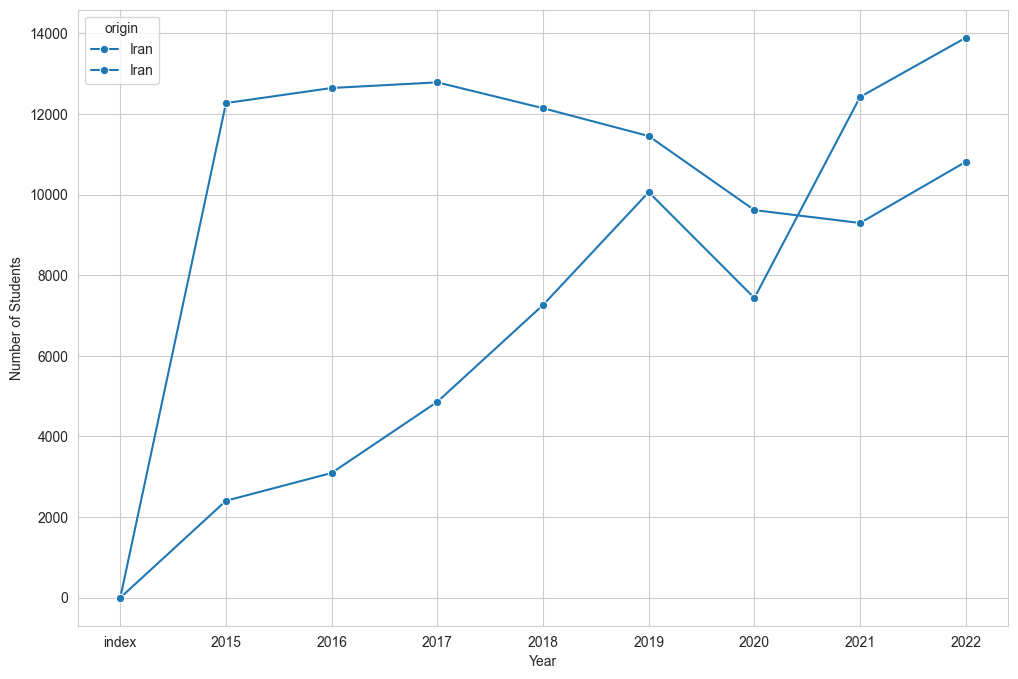

In [51]:
plt.figure(figsize=(12, 8))

c = corr_to_plot[corr_to_plot<0].keys()
c = ["Iran"]
d = us.loc[c].reset_index()
df_long = d.reset_index().melt(id_vars="origin", var_name="Year", value_name="Number of Students")
sns.lineplot(data=df_long, x="Year", y="Number of Students", hue="origin", marker="o")

d = canada.loc[c].reset_index()
df_long = d.reset_index().melt(id_vars="origin", var_name="Year", value_name="Number of Students")


sns.lineplot(data=df_long, x="Year", y="Number of Students", hue="origin", marker="o")
plt.show()

In [52]:
df = result
def cal_diff(s2,s1)->pd.Series:
    
    diff = (s2-s1)#/s1.sum()#/s1.replace(0, 1.0)
    
    #diff = diff / diff.max()*100
    diff = diff / diff.sum()*100
    
    diff = diff.sort_values() # do not work idk
    return diff


diff_US = cal_diff(df['2022_US'] , df['2015_US'])

diff_Canada = cal_diff(df['2022_Canada'] , df['2015_Canada'])

/tmp/ipykernel_1609596/1920250332.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(diff_US.iloc[0:5],palette="Blues_r",ax=ax,legend="Bottom 5 Growth")
/tmp/ipykernel_1609596/1920250332.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(diff_US.iloc[-5:],palette="Reds",ax=ax,legend="Top 5 Growth")
/tmp/ipykernel_1609596/1920250332.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_1609596/1920250332.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to

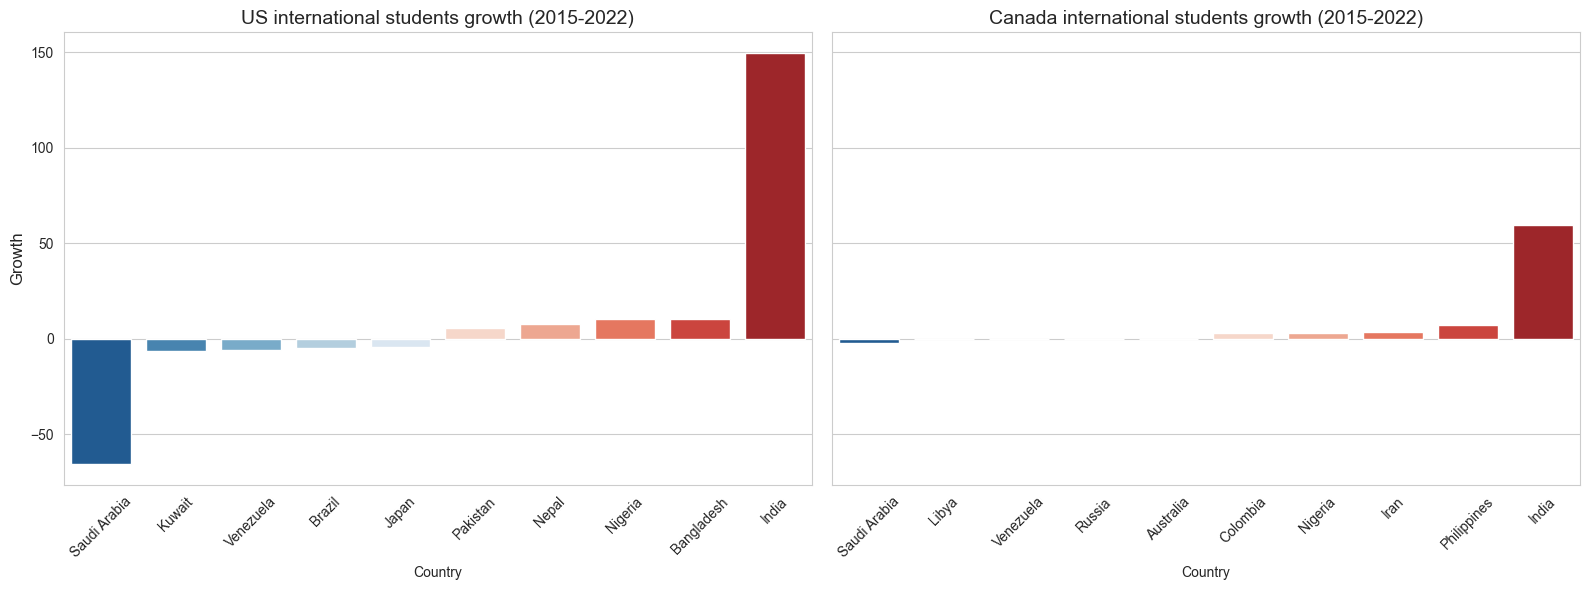

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
axes:list[plt.Axes]
ax = axes[0]
sns.barplot(diff_US.iloc[0:5],palette="Blues_r",ax=ax,legend="Bottom 5 Growth")
sns.barplot(diff_US.iloc[-5:],palette="Reds",ax=ax,legend="Top 5 Growth")
ax.set_xlabel("Country", fontsize=10)
ax.set_ylabel("Growth", fontsize=12)
ax.set_title("US international students growth (2015-2022)", fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

ax = axes[1]
sns.barplot(diff_Canada.iloc[0:5],palette="Blues_r",ax=ax,legend="Bottom 5 Growth")
sns.barplot(diff_Canada.iloc[-5:],palette="Reds",ax=ax,legend="Top 5 Growth")
ax.set_xlabel("Country", fontsize=10)
ax.set_ylabel("Growth", fontsize=12)
ax.set_title("Canada international students growth (2015-2022)", fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()


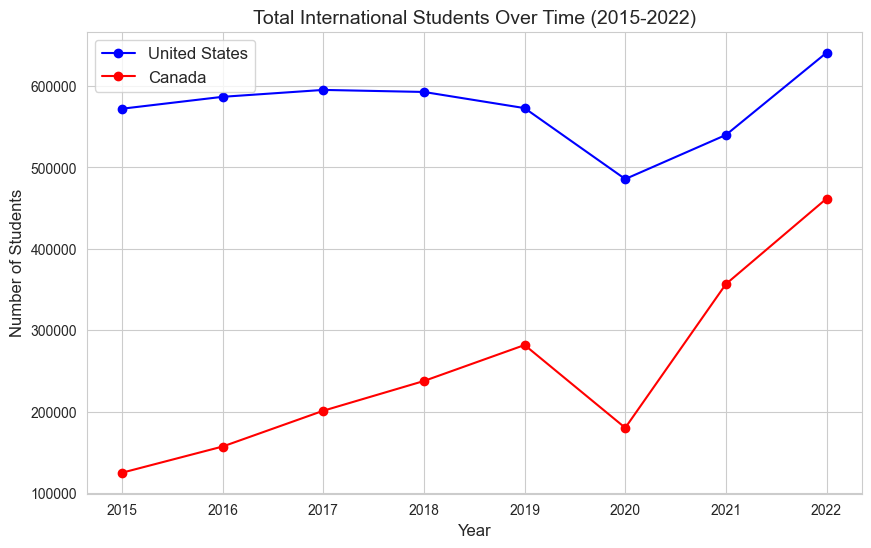

/tmp/ipykernel_1609596/3257237587.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1609596/3257237587.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


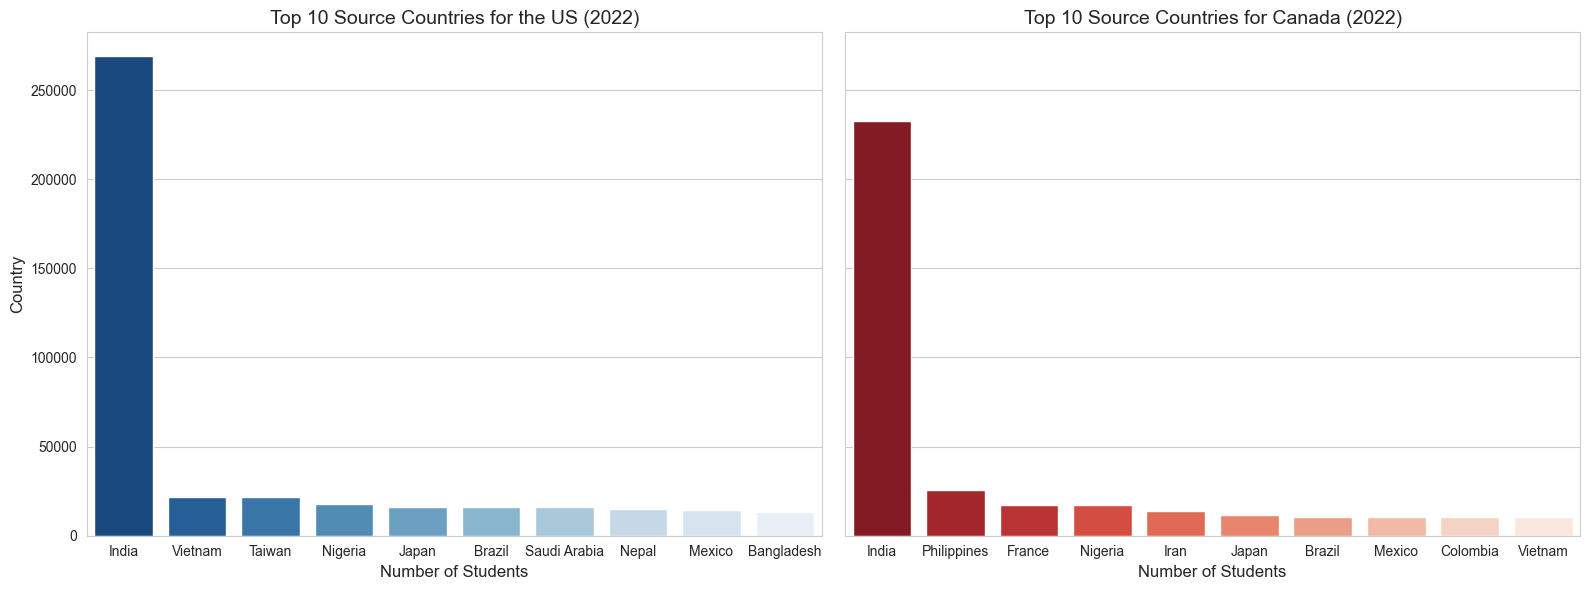

(origin
 India         103005.0
 Bangladesh      7050.0
 Nigeria         6966.0
 Nepal           5428.0
 Pakistan        4023.0
 Ghana           3419.0
 Peru            1914.0
 Spain           1908.0
 Ethiopia        1489.0
 Colombia        1281.0
 Name: US_Growth, dtype: float64,
 origin
 India          200175.0
 Philippines     23820.0
 Iran            11485.0
 Nigeria         10375.0
 Colombia         9270.0
 Vietnam          7385.0
 Nepal            6770.0
 Mexico           6345.0
 Bangladesh       6240.0
 Ukraine          5410.0
 Name: Canada_Growth, dtype: float64)

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

data = df
data_cleaned = data.drop(columns=["Unnamed: 0"])

years = ["2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022"]
total_us = data_cleaned[[f"{year}_US" for year in years]].sum()
total_canada = data_cleaned[[f"{year}_Canada" for year in years]].sum()

plt.figure(figsize=(10, 6))
plt.plot(years, total_us, marker="o", label="United States", color="blue")
plt.plot(years, total_canada, marker="o", label="Canada", color="red")
plt.title("Total International Students Over Time (2015-2022)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

top_countries_us_2022 = data_cleaned.nlargest(10, "2022_US")["2022_US"]
top_countries_canada_2022 = data_cleaned.nlargest(10, "2022_Canada")["2022_Canada"]

fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# US
sns.barplot(
    top_countries_us_2022,
    ax=ax[0],
    palette="Blues_r",
)
ax[0].set_title("Top 10 Source Countries for the US (2022)", fontsize=14)
ax[0].set_xlabel("Number of Students", fontsize=12)
ax[0].set_ylabel("Country", fontsize=12)

# Canada
sns.barplot(
    top_countries_canada_2022,
    ax=ax[1],
    palette="Reds_r",
)
ax[1].set_title("Top 10 Source Countries for Canada (2022)", fontsize=14)
ax[1].set_xlabel("Number of Students", fontsize=12)
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

data_cleaned["US_Growth"] = data_cleaned["2022_US"] - data_cleaned["2015_US"]
data_cleaned["Canada_Growth"] = data_cleaned["2022_Canada"] - data_cleaned["2015_Canada"]

top_growth_us = data_cleaned.nlargest(10, "US_Growth")["US_Growth"]
top_growth_canada = data_cleaned.nlargest(10, "Canada_Growth")["Canada_Growth"]

top_growth_us, top_growth_canada


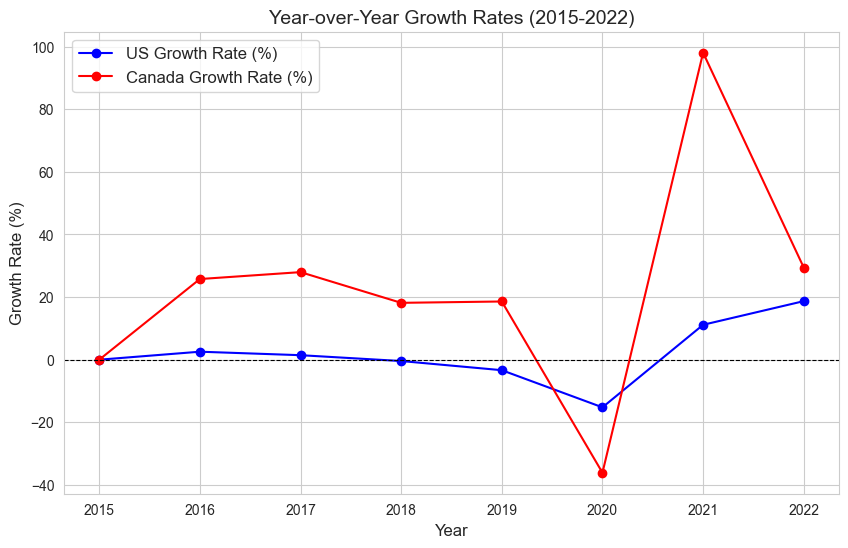

In [55]:
# Calculate percentage growth rates for the US and Canada
us_growth_rate = total_us.pct_change().fillna(0) * 100  # Percentage growth for US
canada_growth_rate = total_canada.pct_change().fillna(0) * 100  # Percentage growth for Canada

# Line Plot: Year-over-Year Growth Rates
plt.figure(figsize=(10, 6))
plt.plot(years, us_growth_rate, marker="o", label="US Growth Rate (%)", color="blue")
plt.plot(years, canada_growth_rate, marker="o", label="Canada Growth Rate (%)", color="red")
plt.title("Year-over-Year Growth Rates (2015-2022)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Growth Rate (%)", fontsize=12)
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)  # Horizontal line at 0
plt.legend(fontsize=12)
plt.grid(True)
plt.show()
